# Tugas Praktikum - K-Means Clustering

Buatlah sebuah model K-Means dengan ketentuan:
1. Gunakan data `Mall_Customers.csv`
2. Tentukan fitur apa yang tepat untuk melakukan clustering (minimal 2)
3. Buatlah model K-Means dengan mempertimbangkan jumlah k yang terbaik

# Persiapan Data

In [1]:
# Persiapan data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv('dataset/Mall_Customers.csv')

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [2]:
# Cek informasi dataset: jumlah data, tipe data, dan missing value
print(f'Jumlah data: {df.shape[0]} pelanggan, {df.shape[1]} kolom')
df.info()

Jumlah data: 200 pelanggan, 5 kolom
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


In [3]:
# Ringkasan statistik tiap kolom
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


# Seleksi Fitur

Fitur yang dipilih (2 fitur, memenuhi ketentuan minimal 2):
- **Annual Income (k$)** → kemampuan belanja pelanggan.
- **Spending Score (1-100)** → seberapa besar pelanggan menghabiskan uangnya.

Kolom `Age` dan `Gender` tidak dipakai sebagai fitur, tetapi digunakan di akhir untuk menginterpretasi setiap klaster.

In [4]:
# Seleksi Fitur
feature_names = ['Annual Income (k$)', 'Spending Score (1-100)']

X = df[feature_names]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


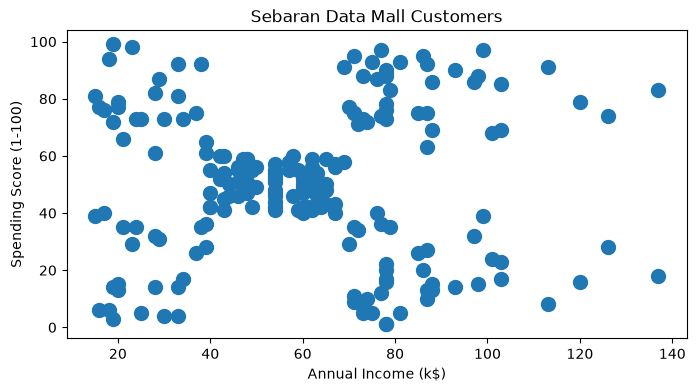

In [5]:
# Plot Data
# Sebaran Annual Income terhadap Spending Score

plt.figure(figsize=(8,4))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Sebaran Data Mall Customers")
plt.show()

In [6]:
# Cek korelasi antar fitur numerik yang kandidat dijadikan fitur
df[['Age'] + feature_names].corr()

,Age,Annual Income (k$),Spending Score (1-100)
Age,1.000000,-0.012398,-0.327227
Annual Income (k$),-0.012398,1.000000,0.009903
Spending Score (1-100),-0.327227,0.009903,1.000000


Karena skala `Annual Income` (15-137) dan `Spending Score` (1-100) berbeda, data distandardisasi lebih dulu agar perhitungannya seimbang.

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

# Menentukan Jumlah k Terbaik

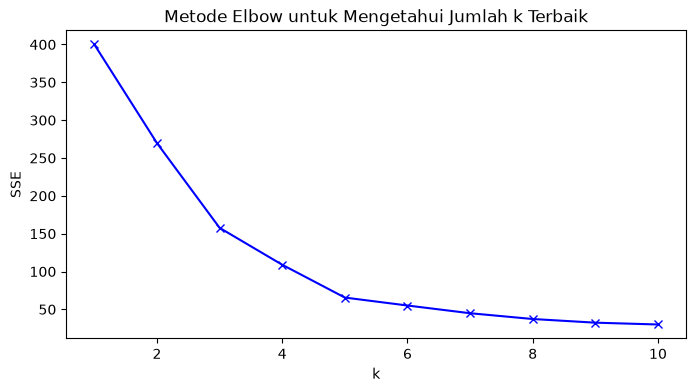

In [8]:
# Implementasi Metode Elbow

# List nilai SSE
sse = []

# Cari k terbaik dari 1-10
K = range(1,11)

# Cek nilai SSE setiap k
for k in K:
 kmeanModel = KMeans(n_clusters=k, random_state=42, n_init=10)
 kmeanModel.fit(X_scaled)
 sse.append(kmeanModel.inertia_)


# Plotting the distortions
plt.figure(figsize=(8,4))
plt.plot(K, sse, "bx-")
plt.xlabel("k")
plt.ylabel("SSE")
plt.title("Metode Elbow untuk Mengetahui Jumlah k Terbaik")
plt.show()

In [9]:
# Cek Nilai SSE setiap k
for idx, sse_val in enumerate(sse, start=1):
    print(f'k={idx}; SSE={sse_val}')

k=1; SSE=399.99999999999994
k=2; SSE=269.69101219276405
k=3; SSE=157.70400815035939
k=4; SSE=108.92131661364358
k=5; SSE=65.56840815571681
k=6; SSE=55.057348270385965
k=7; SSE=44.86475569922555
k=8; SSE=37.22818767758587
k=9; SSE=32.39226763033118
k=10; SSE=29.981897788243703


Metode Elbow dibandingkan dengan Silhouette Coefficient supaya pemilihan k lebih meyakinkan. Silhouette tidak terdefinisi untuk k=1, jadi dihitung mulai k=2.

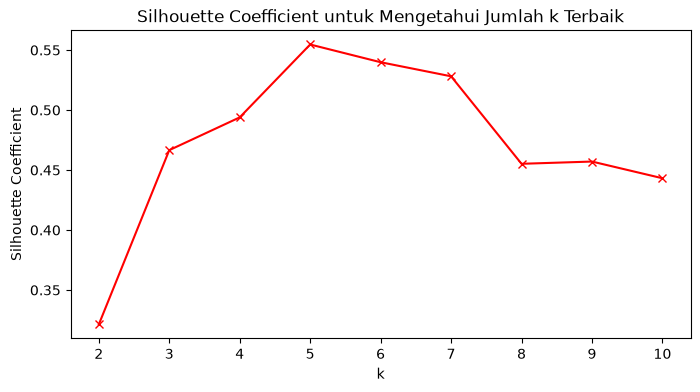

In [10]:
from sklearn.metrics import silhouette_score

# List nilai Silhouette
silhouette = []

# Cari k terbaik dari 2-10
K_sil = range(2,11)

# Cek nilai Silhouette setiap k
for k in K_sil:
 kmeanModel = KMeans(n_clusters=k, random_state=42, n_init=10)
 labels = kmeanModel.fit_predict(X_scaled)
 silhouette.append(silhouette_score(X_scaled, labels))

# Plotting silhouette values
plt.figure(figsize=(8,4))
plt.plot(K_sil, silhouette, "rx-")
plt.xlabel("k")
plt.ylabel("Silhouette Coefficient")
plt.title("Silhouette Coefficient untuk Mengetahui Jumlah k Terbaik")
plt.show()

In [11]:
# Cek Nilai Silhouette setiap k
for idx, sil_val in zip(K_sil, silhouette):
    print(f'k={idx}; Silhouette={sil_val}')

k=2; Silhouette=0.3212707813918878
k=3; Silhouette=0.46658474419000145
k=4; Silhouette=0.4939069237513199
k=5; Silhouette=0.554657163111109
k=6; Silhouette=0.5398800926790663
k=7; Silhouette=0.5281492781108291
k=8; Silhouette=0.4552147906587443
k=9; Silhouette=0.4570853966942764
k=10; Silhouette=0.4431713026508046


Penurunan SSE melambat secara tajam setelah **k=5** (titik siku): dari k=4 ke k=5 turun 43.3, tetapi dari k=5 ke k=6 hanya turun 10.5. Nilai Silhouette juga mencapai tertinggi pada **k=5** (0.555). Kedua metode saling menguatkan, maka jumlah klaster terbaik adalah **k = 5**.

# Pembuatan Model K-Means

In [12]:
# Buat Model KMeans
# Gunakan k=5 sebagai jumlah klaster terbaik hasil metode Elbow dan Silhouette

n_best_k = 5

# Inisiasi obyek KMeans
cl_kmeans = KMeans(n_clusters=n_best_k, random_state=42, n_init=10)

# Fit dan predict model
y_kmeans = cl_kmeans.fit_predict(X_scaled)

df['Cluster'] = y_kmeans

In [13]:
# Cek Nilai SSE
print(f'Nilai SSE: {cl_kmeans.inertia_}')

Nilai SSE: 65.56840815571681


In [14]:
# Cek jumlah anggota setiap klaster
df['Cluster'].value_counts().sort_index()

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

# Visualisasi Hasil Klasterisasi

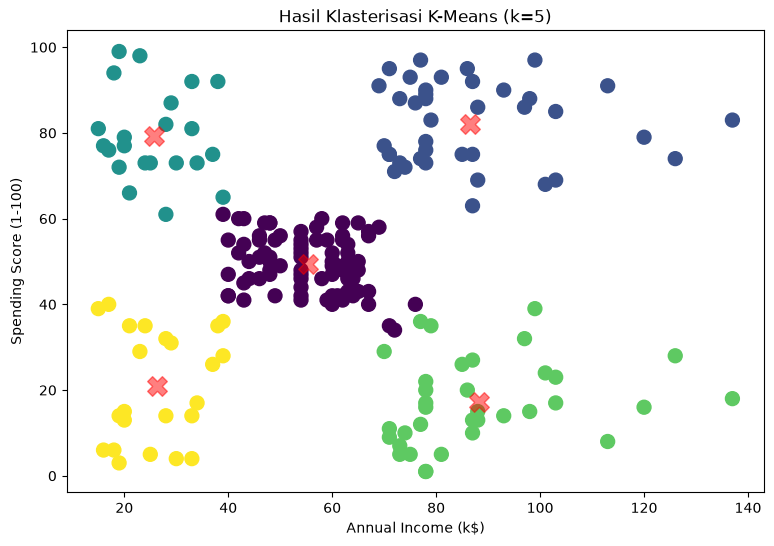

In [15]:
# Plot hasil cluster berdasarkan Annual Income dan Spending Score
plt.figure(figsize=(9,6))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100, c=y_kmeans, cmap='viridis')

# Plot centroid
centers = scaler.inverse_transform(cl_kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5, marker='X')

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Hasil Klasterisasi K-Means (k=5)")
plt.show()

In [16]:
# Cek nilai centroid setiap klaster pada skala asli data
pd.DataFrame(
    centers,
    columns=feature_names,
    index=range(n_best_k)
).round(2)

,Annual Income (k$),Spending Score (1-100)
0,55.30,49.52
1,86.54,82.13
2,25.73,79.36
3,88.20,17.11
4,26.30,20.91


# Interpretasi Hasil

In [17]:
# Profil rata-rata setiap klaster (termasuk Age yang tidak dijadikan fitur)
df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(2)

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.72,55.30,49.52
1,32.69,86.54,82.13
2,25.27,25.73,79.36
3,41.11,88.20,17.11
4,45.22,26.30,20.91


In [18]:
# Komposisi Gender pada setiap klaster
pd.crosstab(df['Cluster'], df['Gender'])

Gender,Female,Male
Cluster,,
0,48,33
1,21,18
2,13,9
3,16,19
4,14,9


👉 **Interpretasi visual:**

- Sumbu mendatar adalah Annual Income, sumbu tegak adalah Spending Score, dan warna menunjukkan klaster hasil K-Means.
- Titik merah bentuk X adalah centroid (pusat) dari setiap klaster.

Berdasarkan nilai centroid pada skala asli data:

- **Klaster 0** (Income 55.3, Spending 49.5, usia rata-rata 42.7) → pendapatan dan belanja menengah: pelanggan stabil, cocok dipertahankan dengan program loyalitas.
- **Klaster 1** (Income 86.5, Spending 82.1, usia rata-rata 32.7) → pendapatan tinggi dan belanja tinggi: pelanggan VIP, prioritas layanan dan reward.
- **Klaster 2** (Income 25.7, Spending 79.4, usia rata-rata 25.3) → pendapatan rendah tetapi belanja tinggi: paling muda dan konsumtif, perlu diawasi karena pengeluaran melebihi kemampuan.
- **Klaster 3** (Income 88.2, Spending 17.1, usia rata-rata 41.1) → pendapatan tinggi tetapi belanja rendah: potensi yang belum tergarap, cocok ditawarkan produk premium.
- **Klaster 4** (Income 26.3, Spending 20.9, usia rata-rata 45.2) → pendapatan rendah dan belanja rendah: pelanggan hemat, cocok dengan promo hemat.

Model dinilai layak karena SSE pada k=5 sudah berada di titik siku dan Silhouette Coefficient tertinggi (0.555) pada k yang sama, artinya kelima klaster terbentuk terpisah dengan cukup baik.